# Track Occupancy Classifier


In [ ]:
from pathlib import Path
from fastai.vision.all import defaults, default_device
import torch
import os
import yaml

os.chdir("/Users/boser/iot/track-occupancy/cnn")

with open("../config.yaml", "r") as f:
    cfg = yaml.safe_load(f)

default_device(torch.device("mps"))
print(f"DEVICE cuda: {defaults.use_cuda} on {defaults.cpus} cpus")

# Training / Validation data
REBUILD_DB = False
DATA_DIR = Path("../dataset/data")

# CNN parameters
TRAIN = False
THRESHOLD = 0.6
EPOCHS = 3
FREEZE_EPOCHS = 1
LEARNING_RATE = 0.001
MODEL_NAME = "model"

CROPPED_SIZE = cfg["CROP_SIZE_UI"]
SAMPLE_DPT = cfg["SAMPLE_DPT"]

print(
    f"Training model for {CROPPED_SIZE} x {CROPPED_SIZE} pixel images @ {SAMPLE_DPT} dpt"
)
print(f"Trained model is at {DATA_DIR}/{MODEL_NAME}.onnx")


DEVICE cuda: mps on 12 cpus
Training model for 96 x 96 pixel images @ 20 dpt
Trained model is at ../dataset/data/model.onnx


In [3]:
# Prepare Database

import os
import subprocess
import pandas as pd

if REBUILD_DB:
    # Change directory
    os.chdir("/Users/boser/iot/track-occupancy/cnn")

    # Run shell command (capturing output)
    subprocess.run("cd ../dataset && pnpm run prep", shell=True, check=True)


df = pd.read_csv(DATA_DIR / "data.csv")
df.head()


,label_id,labels,is_valid,archive
0,3f2089c1-8f0d-4441-a71e-e627a466eb71,track,True,cars 0-10.r49
1,cf01ab17-75df-435f-8f55-c6ab76eb9f84,track,False,cars 0-10.r49
2,65fe03b4-d1b3-477a-9aba-883593b6e228,track,False,cars 0-10.r49
3,af9b00d4-4850-41cd-b62b-c04e48ed852e,track,False,cars 0-10.r49
4,7bfdd477-80b0-4522-b417-fb6c62048fb6,track,False,cars 0-10.r49


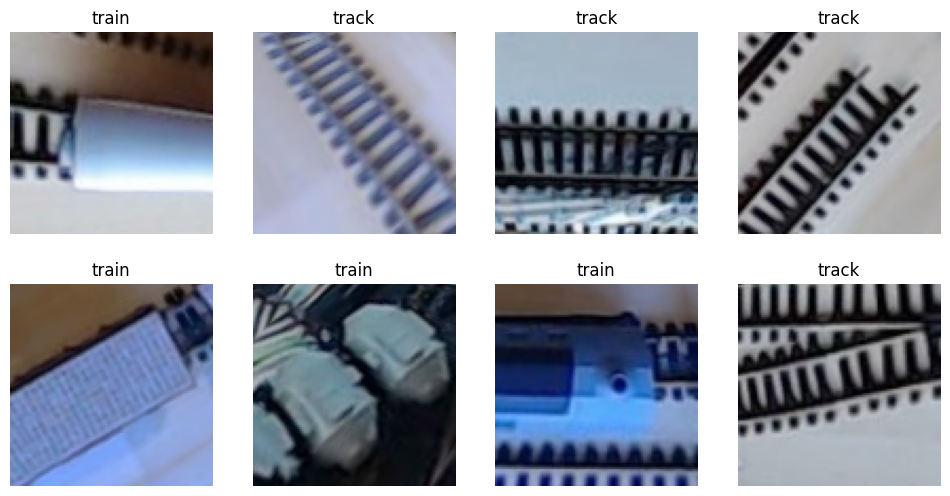

In [4]:
# Load Training/Validation Data

from fastai.vision.all import (
    DataBlock,
    ImageBlock,
    MultiCategoryBlock,
    ColSplitter,
    CropPad,
    Normalize,
    aug_transforms,
)


def get_x(r):
    return DATA_DIR / f"{r['label_id']}.jpg"


def get_y(r):
    return r["labels"].split(" ")


item_tfms = CropPad(CROPPED_SIZE)
batch_tfms = [
    *aug_transforms(
        max_rotate=80.0,
        max_lighting=0.2,
        do_flip=True,
        max_zoom=1.1,
    ),
    Normalize.from_stats(cfg["IMAGENET_MEAN"], cfg["IMAGENET_STD"]),
]

dblock = DataBlock(
    blocks=(ImageBlock, MultiCategoryBlock),
    get_x=get_x,
    get_y=get_y,
    splitter=ColSplitter("is_valid"),
    item_tfms=item_tfms,
    batch_tfms=batch_tfms,
)

dls = dblock.dataloaders(df)

dls.show_batch(nrows=2, ncols=4)


In [5]:
from fastai.vision.all import vision_learner, resnet18
from functools import partial


def accuracy_multi(inp, targ, thresh=0.5, sigmoid=True):
    "Compute accuracy when `inp` and `targ` are the same size."
    if sigmoid:
        inp = inp.sigmoid()
    return ((inp > thresh) == targ.bool()).float().mean()


# TODO: optimization - cut off 4 fully connected layers at output to match smaller input
# (96 vs 224 pixels)

learn = vision_learner(dls, resnet18, metrics=partial(accuracy_multi, thresh=THRESHOLD))

try:
    learn.load(MODEL_NAME)
    print("Starting from previously trained model")
except FileNotFoundError:
    print("No pretrained model found")

if TRAIN:
    learn.fine_tune(EPOCHS, base_lr=LEARNING_RATE, freeze_epochs=FREEZE_EPOCHS)
    learn.save(MODEL_NAME)


Starting from previously trained model


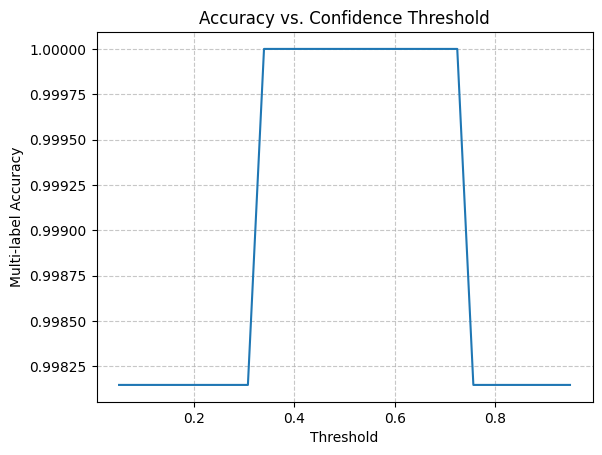

In [6]:
import torch
import matplotlib.pyplot as plt

learn.metrics = partial(accuracy_multi, thresh=0.1)
learn.validate()

preds, targs = learn.get_preds()
accuracy_multi(preds, targs, thresh=0.9, sigmoid=False)

xs = torch.linspace(0.05, 0.95, 29)
accs = [accuracy_multi(preds, targs, thresh=i, sigmoid=False) for i in xs]
plt.plot(xs, accs)

# Adding descriptive labels
plt.title("Accuracy vs. Confidence Threshold")
plt.xlabel("Threshold")
plt.ylabel("Multi-label Accuracy")
plt.grid(True, linestyle="--", alpha=0.7)

,target,predicted,probabilities,loss
0,track,track,"tensor([4.5653e-05, 7.2628e-01, 3.1262e-01])",0.23157481849193573
1,train,train,"tensor([4.6996e-02, 8.2710e-07, 1.0000e+00])",0.01604592800140381
2,train,train,"tensor([4.4302e-03, 5.5539e-08, 1.0000e+00])",0.001480142236687243
3,train,train,"tensor([4.0685e-05, 8.0477e-04, 9.9912e-01])",0.0005741428467445076
4,coupling;train,coupling;train,"tensor([9.9880e-01, 2.7257e-06, 1.0000e+00])",0.0004018132749479264
5,train,train,"tensor([6.0806e-06, 1.4141e-04, 9.9990e-01])",8.320631604874507e-05
6,coupling;train,coupling;train,"tensor([9.9979e-01, 4.3751e-07, 1.0000e+00])",7.0167203375604e-05
7,train,train,"tensor([1.9952e-04, 3.2649e-07, 1.0000e+00])",6.651878356933594e-05
8,train,train,"tensor([1.4765e-04, 7.7772e-08, 1.0000e+00])",4.927317422698252e-05


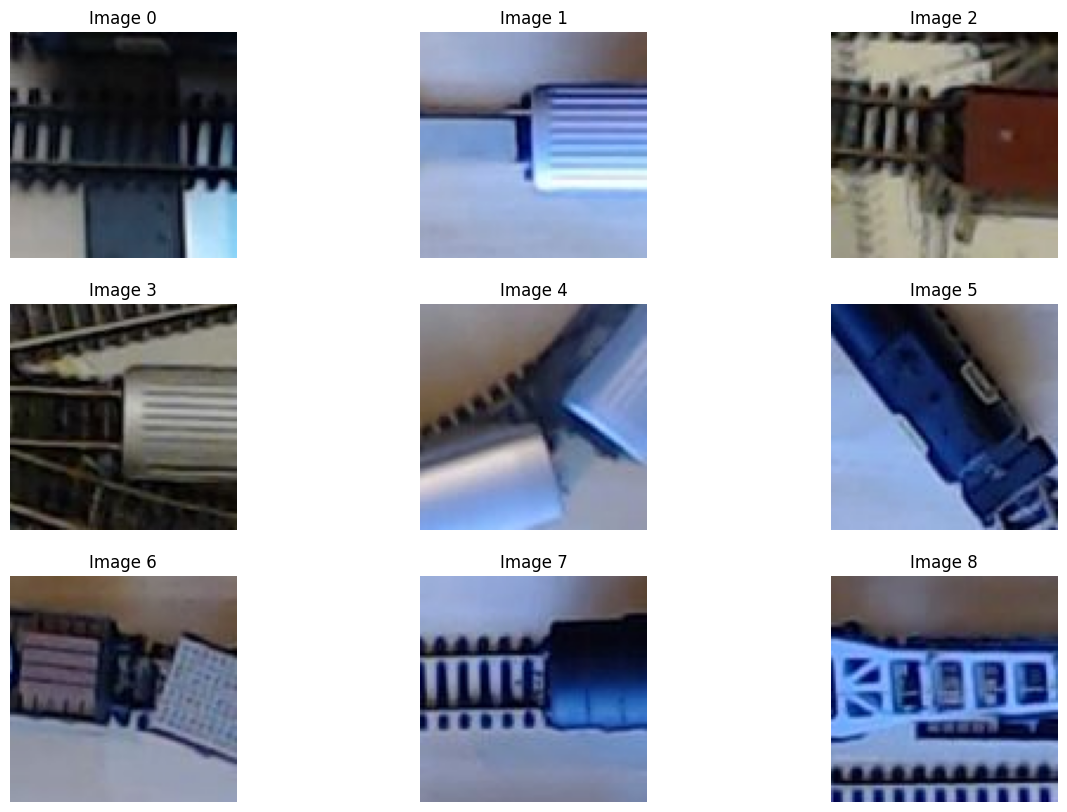

In [7]:
from fastai.vision.all import ClassificationInterpretation

interp = ClassificationInterpretation.from_learner(learn)

# Makes no sense for multi-label problem!
# interp.plot_confusion_matrix()

interp.plot_top_losses(9, figsize=(15, 10))


In [8]:
print("Classification errors:")

N = 0

for i, row in df.iterrows():
    pred = learn.predict(DATA_DIR / f"{row['label_id']}.jpg")[0]
    rev = list(pred)
    rev.reverse()
    error = row["labels"] != " ".join(rev)
    if error:
        print(i, row["label_id"], row["labels"], " =?=", " ".join(pred), error)
        N += 1
    # BUG: final print statement never reached without this break ?!?
    if i > 400:
        break


print(f"{N} errors")

Classification errors:


0 errors


In [9]:
from fastai.vision.all import PILImage, show_image

# 1. Get predictions for the entire validation set (or dls.train for the whole thing)
preds, targs = learn.get_preds(dl=dls.valid)

# 2. Convert predictions to boolean (using your chosen threshold)
thresh = THRESHOLD
pred_bools = preds > thresh

# 3. Find which ones don't match the targets exactly
# (all(dim=1) ensures every single label in the multi-label set must match)
is_error = ~(pred_bools == targs.bool()).all(dim=1)
error_indices = torch.where(is_error)[0]
print(f"Found {len(error_indices)} misclassified samples out of {len(targs)}.")

# 4. Display the errors
vocab = dls.vocab
for idx in error_indices:
    # Get the actual labels and predicted labels
    actual = [vocab[i] for i, val in enumerate(targs[idx]) if val == 1]
    predicted = [vocab[i] for i, val in enumerate(pred_bools[idx]) if val]

    # Get the filename (assuming the order in dls.valid matches your items)
    # Fastai stores the original items in dl.items
    fn = dls.valid.items.iloc[idx.item()]["label_id"]

    print(f"Index: {idx.item()} | File: {fn}")
    print(f"  Actual:    {actual}")
    print(f"  Predicted: {predicted}")
    print("-" * 20)

    fn = dls.valid.items.iloc[idx.item()]["label_id"]

    # Load path
    img_path = DATA_DIR / f"{fn}.jpg"
    img = PILImage.create(img_path)

    # Show image with labels
    ax = show_image(img, title=f"Actual: {actual}\nPred: {predicted}")
    plt.show()  # Forces the notebook to show the image before continuing the loop

Found 0 misclassified samples out of 180.


In [10]:
# TODO: Model Quantization - fasterai?


In [ ]:
# Export model

from onnxruntime.tools.convert_onnx_models_to_ort import (
    OptimizationStyle,
    convert_onnx_models_to_ort,
)
import torch
import json

# 1. Prepare model
model = learn.model.cpu()
model.eval()

# 2. Create dummy input
dummy_input = torch.randn(1, 3, CROPPED_SIZE, CROPPED_SIZE)

# 3. TRACE the model first (this forces the legacy ONNX path)
traced_model = torch.jit.trace(model, dummy_input)

# 4. Export the TRACED model
onnx_path = "models/model.onnx"
torch.onnx.export(
    traced_model,  # Use traced_model here
    dummy_input,
    onnx_path,
    export_params=True,
    do_constant_folding=True,
    input_names=["input"],
    output_names=["output"],
    opset_version=18,
    dynamic_axes={"input": {0: "batch_size"}, "output": {0: "batch_size"}},
    dynamo=False,
)

# 5. Convert to ORT
try:
    convert_onnx_models_to_ort(
        Path(onnx_path), optimization_styles=[OptimizationStyle.Fixed]
    )
except Exception as e:
    print(f"Failed to convert to ORT: {e}")

# 6. Write config.json
with open("models/config.json", "w") as f:
    json.dump(
        {
            "labels": list(dls.vocab),
            "dpt": SAMPLE_DPT,
            "crop_size": CROPPED_SIZE,
            "mean": cfg["IMAGENET_MEAN"],
            "std": cfg["IMAGENET_STD"],
            "threshold": THRESHOLD,
        },
        f,
        indent=2,
    )


/var/folders/ym/p6gv14tn4w32d2m3zj3l_rkm0000gn/T/ipykernel_22478/658722040.py:22: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(
2026-05-14 12:35:15,781 ort_format_model.utils [INFO] - Created config in /Users/boser/iot/track-occupancy/cnn/models/model.required_operators.config


Converting models with optimization style 'Fixed' and level 'all'
Converting optimized ONNX model /Users/boser/iot/track-occupancy/cnn/models/model.onnx to ORT format model /Users/boser/iot/track-occupancy/cnn/models/model.ort
Converted 1/1 models successfully.
Generating config file from ORT format models with optimization style 'Fixed' and level 'all'
converted to ort models/model.onnx


In [12]:
# Compare ONNX and Fastai models on validation set...

import numpy as np
import onnxruntime as ort

# 1. Load the ONNX session
# 'cpu' is default; use 'TensorrtExecutionProvider' or 'CoreMLExecutionProvider' for hardware accel
ort_session = ort.InferenceSession("models/model.onnx")

# 2. Get the input name (usually "input" as defined in your export)
input_name = ort_session.get_inputs()[0].name

all_onnx_preds = []
all_fastai_preds = []
all_targets = []

with torch.no_grad():
    for x, y in dls.valid:
        # Move to CPU to match model
        x_cpu = x.cpu()

        # ONNX Prediction
        x_numpy = x_cpu.numpy()
        batch_onnx = ort_session.run(None, {input_name: x_numpy})[0]

        # Fastai (PyTorch) Prediction
        batch_fastai = learn.model(x_cpu).cpu().numpy()

        all_onnx_preds.append(batch_onnx)
        all_fastai_preds.append(batch_fastai)
        all_targets.append(y.cpu().numpy())

all_onnx_preds = np.concatenate(all_onnx_preds)
all_fastai_preds = np.concatenate(all_fastai_preds)
all_targets = np.concatenate(all_targets)

# Compare
max_diff = np.abs(all_onnx_preds - all_fastai_preds).max()
avg_diff = np.abs(all_onnx_preds - all_fastai_preds).mean()
matches = np.allclose(all_onnx_preds, all_fastai_preds, atol=1e-5)

print("Comparison complete:")
print(f" - Max difference: {max_diff:.2e}")
print(f" - Avg difference: {avg_diff:.2e}")
print(f" - Matches (atol=1e-5): {matches}")


Comparison complete:
 - Max difference: 1.45e-04
 - Avg difference: 1.41e-05
 - Matches (atol=1e-5): False
